# **MultiModal RAG App for Video Processing With LlamaIndex and LanceDB**

### 1. llamaindex framework
### 2. Lancedb Vector DataBase
### 3. LLM MultiModAl GPT-4V or Google-gemini-pro-vision


# **Steps Need to follow:**
#### 1. Download video from YouTube, process and store it.

#### 2. Build Multi-Modal index and vector store for both texts and images.

#### 3. Retrieve relevant images and context, use both to augment the prompt.

#### 4. Using GPT4V for reasoning the correlations between the input query and augmented data and generating final response.

In [ ]:
%pip install --upgrade llama-index-vector-stores-lancedb
%pip install --upgrade llama-index-multi-modal-llms-gemini
%pip install --upgrade llama-index-embeddings-clip
%pip install --upgrade llama-index-embeddings-gemini
%pip install --upgrade git+https://github.com/openai/CLIP.git
!pip install --upgrade llama-index-readers-file
%pip install --upgrade llama-index-llms-google-genai
%pip install --upgrade llama-index

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-vnpghsi1
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-vnpghsi1
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done


In [ ]:
%pip install llama_index
%pip install -U openai-whisper

INFO: pip is looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.1.1
    Uninstalling wrapt-2.1.1:
      Successfully uninstalled wrapt-2.1.1
  Attempting uninstall: deprecated
    Found existing 

In [ ]:
%pip install lancedb
%pip install moviepy
%pip install pytube
%pip install pydub
%pip install SpeechRecognition
%pip install ffmpeg-python
%pip install soundfile
%pip install torch torchvision
%pip install matplotlib scikit-image
%pip install ftfy regex tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 52.7 MB/s eta 0:00:00


In [ ]:
!pip install pytubefix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 MB 12.6 MB/s eta 0:00:00


ffmpeg-library enables you to use FFmpeg in Python to manipulate various media files for different purposes like building comprehensive multimedia applications, preprocessing media files.

MoviePy is a Python library for video editing, enabling cutting, concatenations, title insertions, video compositing, and effects like animations or color grading.

Pytube is a Python library used for downloading videos from YouTube. It supports downloading in various formats, resolutions, and also direct audio extraction.


Pydub is a Python library for audio manipulation, enabling easy loading,
editing, and exporting of audio files in various formats with minimal code.

The SpeechRecognition library in Python allows you to convert spoken language into text using various engines and APIs, such as Google Speech Recognition, IBM Speech to Text, etc.


SoundFile is a Python library for reading from and writing to audio files, supporting many formats through the libsndfile library, ideal for high-quality audio processing.

FTFY (Fix Text For You) is a Python library that fixes broken Unicode text and mojibake (garbled text due to encoding issues), making text legible again.

OpenAI Whisper is a robust, multilingual speech recognition model developed by OpenAI. It converts speech into text and supports various languages with high accuracy.

pprint is a Python module that provides a capability to "pretty-print" complex data structures in a well-formatted and more readable way than the basic print function.

In [ ]:
from moviepy.video.io.VideoFileClip import VideoFileClip
from pathlib import Path
import speech_recognition as sr
from pytube import YouTube
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt
import nest_asyncio

nest_asyncio.apply()

In [ ]:
import os
from google.colab import userdata
GEMINI_API_TOKEN=userdata.get('GEMINI_API_KEY')
os.environ["GEMINI_API_KEY"] = GEMINI_API_TOKEN

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
video_url="https://youtu.be/3dhcmeOTZ_Q"

In [ ]:
output_video_path = "/content/video_data/"

In [ ]:
# from the video i am going to collect images,audio,text
output_folder = "/content/mixed_data/"
output_audio_path = "/content/mixed_data/output_audio.wav"

In [ ]:
!mkdir mixed_data

mkdir: cannot create directory ‘mixed_data’: File exists


In [ ]:
filepath=output_video_path + "input_vid.mp4"
print(filepath)

/content/video_data/input_vid.mp4


In [ ]:
from pytubefix import YouTube
def download_video(url,output_path):
  yt = YouTube(url)
  metadata = {"Author": yt.author, "Title": yt.title, "Views": yt.views}

  yt.streams.get_highest_resolution().download(
        output_path=output_path, filename="input_vid.mp4"
    )
  return metadata

In [ ]:
from moviepy.video.io.VideoFileClip import VideoFileClip
def video_to_images(video_path,output_folder):
  clip=VideoFileClip(video_path)
  clip.write_images_sequence(
      os.path.join(output_folder,"frame%04d.png"),fps=0.2
  )

In [ ]:
def video_to_audio(video_path,output_audio_path):
  clip=VideoFileClip(video_path)
  audio=clip.audio
  audio.write_audiofile(output_audio_path)

In [ ]:
def audio_to_text(audio_path):
  recognizer=sr.Recognizer()
  audio=sr.AudioFile(audio_path)

  with audio as source:
    audio_data=recognizer.record(source)

    try:

      #recognize the speech
      text = recognizer.recognize_whisper(audio_data)

    except sr.UnknownValueError:
      print("Speech recognition could not understand the audio.")
  return text

In [ ]:
video_url

'https://youtu.be/3dhcmeOTZ_Q'

In [ ]:
output_video_path

'/content/video_data/'

In [ ]:
metadata_vid = download_video(video_url, output_video_path)

In [ ]:
metadata_vid

{'Author': '3-Minute Data Science',
 'Title': 'Linear Regression in 3 Minutes',
 'Views': 241999}

In [ ]:
video_to_images(filepath,output_folder)

Moviepy - Writing frames /content/mixed_data/frame%04d.png.


Moviepy - Done writing frames /content/mixed_data/frame%04d.png.


In [ ]:
filepath

'/content/video_data/input_vid.mp4'

In [ ]:
output_audio_path

'/content/mixed_data/output_audio.wav'

In [ ]:
video_to_audio(filepath,output_audio_path)

MoviePy - Writing audio in /content/mixed_data/output_audio.wav


MoviePy - Done.


In [ ]:
text_data=audio_to_text(output_audio_path)

In [ ]:
text_data

" Lanyard regression is a statistical technique for modeling the relationship between an output variable and one or more input variables. In layman's terms, think of it as fitting a line through some data points as shown here, so you can make predictions on unknown data, assuming there is a linear relationship between the variables. You might be familiar with the linear function y equals mx plus b, where y is the output variable, also called the dependent variable. You may also see expressed as f of x, the function of the input variable. x on the other hand, would serve as the input variable, also called the independent variable. It's likely you'll see the coefficients m and b expressed as beta 1 and beta 0 respectively. So what do the m and b coefficients do? The m or beta 1 coefficient controls the slope of the line. The b or the beta 0 controls the intercept of the line. In machine learning, we also know it as the bias. These two coefficients are what we are solving for in linear re

In [ ]:
with open(output_folder + "output_text.txt", "w") as file:
        file.write(text_data)
print("Text data saved to file")
file.close()


Text data saved to file


In [ ]:
os.remove(output_audio_path)
print("Audio file removed")

Audio file removed


In [ ]:
#process the video
#image
#text

In [ ]:
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader
from llama_index.core import StorageContext

In [ ]:
from llama_index.vector_stores.lancedb import LanceDBVectorStore

In [ ]:
text_store=LanceDBVectorStore(uri="lancedb",table_name="text_collection")
image_store=LanceDBVectorStore(uri="lancedb",table_name="image_collection")

In [ ]:
storage_context=StorageContext.from_defaults(vector_store=text_store,image_store=image_store)

In [ ]:
output_folder

'/content/mixed_data/'

In [ ]:
documents=SimpleDirectoryReader(output_folder).load_data()

In [ ]:
!pip install llama-index-embeddings-google-genai

In [ ]:
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding

gemini_embed_model = GoogleGenAIEmbedding(
    model_name="models/gemini-embedding-001",
    api_key=GEMINI_API_TOKEN
)

clip_embed_model = ClipEmbedding()

index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    embed_model=gemini_embed_model,
    image_embed_model=clip_embed_model
)

In [ ]:
retriever_engine=index.as_retriever(similarity_top_k=1, image_similarity_top_k=5)

In [ ]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [ ]:
def retrieve(retriever_engine, query_str):
    retrieval_results = retriever_engine.retrieve(query_str)

    retrieved_image = []
    retrieved_text = []
    for res_node in retrieval_results:
        if isinstance(res_node.node, ImageNode):
            retrieved_image.append(res_node.node.metadata["file_path"])
        else:
            display_source_node(res_node, source_length=200)
            retrieved_text.append(res_node.text)

    return retrieved_image, retrieved_text

In [ ]:
query="can you tell me what is linear regression? explain equation of the multiple linear regression?"

In [ ]:
img,text=retrieve(retriever_engine,query)

**Node ID:** 5b7091a0-7b8d-4832-8d12-1aa80d64972b<br>**Similarity:** 0.5628219246864319<br>**Text:** Lanyard regression is a statistical technique for modeling the relationship between an output variable and one or more input variables. In layman's terms, think of it as fitting a line through some...<br>

In [ ]:
import matplotlib.pyplot as plt
def plot_images(images_path):
  images_shown = 0
  plt.figure(figsize=(16, 9))
  for img_path in images_path:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 5:
                break

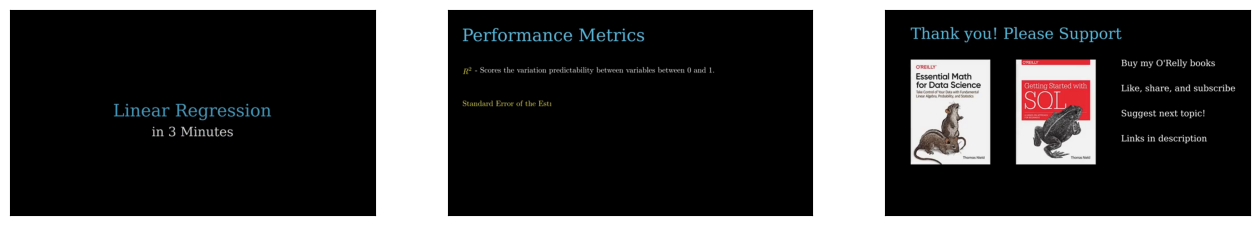

In [ ]:
plot_images(img)

In [ ]:
qa_tmpl_str=(
    "Based on the provided information, including relevant images and retrieved context from the video, \
    accurately and precisely answer the query without any additional prior knowledge.\n"

    "---------------------\n"
    "Context: {context_str}\n"
    "Metadata for video: {metadata_str} \n"

    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)

In [ ]:
img

['/content/mixed_data/frame0003.png',
 '/content/mixed_data/frame0038.png',
 '/content/mixed_data/frame0042.png']

In [ ]:
import json
metadata_str=json.dumps(metadata_vid)

In [ ]:
query_str="can you tell me what is linear regression and equation of linear regression?"

In [ ]:
context_str = "".join(text)

In [ ]:
image_documents = SimpleDirectoryReader( input_files=img).load_data()

In [ ]:
%pip install llama-index-multi-modal-llms-gemini

In [ ]:
from llama_index.llms.google_genai import GoogleGenAI

In [ ]:
Gemini_mm_llm = GoogleGenAI(model="gemini-2.5-flash", api_key=GEMINI_API_TOKEN, max_new_tokens=1500)

In [ ]:
result=Gemini_mm_llm.complete(
    prompt=qa_tmpl_str.format(
        query_str=query_str,metadata_str=metadata_str, context_str=context_str
    ),
    image_documents=image_documents,
)

In [ ]:
print(result.text)

Linear regression is a statistical technique used for modeling the relationship between an output variable and one or more input variables. It involves fitting a line through data points to make predictions on unknown data, assuming a linear relationship between the variables.

The equation of linear regression is commonly expressed as:
**y = mx + b**

Where:
*   **y** is the output variable (dependent variable).
*   **x** is the input variable (independent variable).
*   **m** is the coefficient that controls the slope of the line (also known as beta 1 or $\beta_1$).
*   **b** is the coefficient that controls the intercept of the line (also known as beta 0 or $\beta_0$, or the bias in machine learning).

This equation can also be seen as **y = $\beta_1$x + $\beta_0$**. For multiple input variables, it extends to include additional terms like $\beta_1$x$_1$ + $\beta_2$x$_2$ + $\beta_3$x$_3$, and so on.


In [ ]:
qa_tmpl_str=(
    "Based on the provided information, including relevant images and retrieved context from the video, \
    accurately and precisely answer the query without any additional prior knowledge.\n"

    "---------------------\n"
    "Metadata for video: {metadata_str} \n"

    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)